# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [1]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

Note: you may need to restart the kernel to use updated packages.


Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [2]:
# A.1 — spec table
# Two candidates are loaded and measured directly from their configs/weights.
# gpt2-medium is entered from the published spec in the brief and NEVER downloaded.

def spec_from_loaded(name, model):
    cfg = model.config
    return {
        "model": name,
        "layers": cfg.n_layer,
        "width (d_model)": cfg.n_embd,
        "heads": cfg.n_head,
        "head_dim": cfg.n_embd // cfg.n_head,
        "context": cfg.n_positions,
        "vocab": cfg.vocab_size,
        "params (measured)": sum(p.numel() for p in model.parameters()),
        "source": "loaded + measured",
    }

specs = [spec_from_loaded(n, m) for n, m in models.items()]

# gpt2-medium: paper-only candidate (24 layers, 1024 width, 16 heads, ~355M reference)
specs.append({
    "model": "gpt2-medium",
    "layers": 24,
    "width (d_model)": 1024,
    "heads": 16,
    "head_dim": 1024 // 16,
    "context": 1024,
    "vocab": 50257,
    "params (measured)": None,          # not downloaded — predicted in Part B
    "source": "published spec (not run)",
})

spec_df = pd.DataFrame(specs).set_index("model")
spec_df["params (measured)"] = spec_df["params (measured)"].map(
    lambda v: f"{int(v):,}" if pd.notna(v) else "— (see B.2)"
)
print("Table A.1 — Candidate specifications")
spec_df

Table A.1 — Candidate specifications


,layers,width (d_model),heads,head_dim,context,vocab,params (measured),source
model,,,,,,,,
distilgpt2,6,768,12,64,1024,50257,"81,912,576",loaded + measured
gpt2,12,768,12,64,1024,50257,"124,439,808",loaded + measured
gpt2-medium,24,1024,16,64,1024,50257,— (see B.2),published spec (not run)


Table A.2 — Component census (parameter counts)
model       distilgpt2        gpt2
component                         
embeddings  39,383,808  39,383,808
attention   14,174,208  28,348,416
ffn         28,334,592  56,669,184
layernorm       19,968      38,400

Table A.2b — Component shares (% of total parameters)
model       distilgpt2   gpt2
component                    
embeddings       48.08  31.65
attention        17.30  22.78
ffn              34.59  45.54
layernorm         0.02   0.03


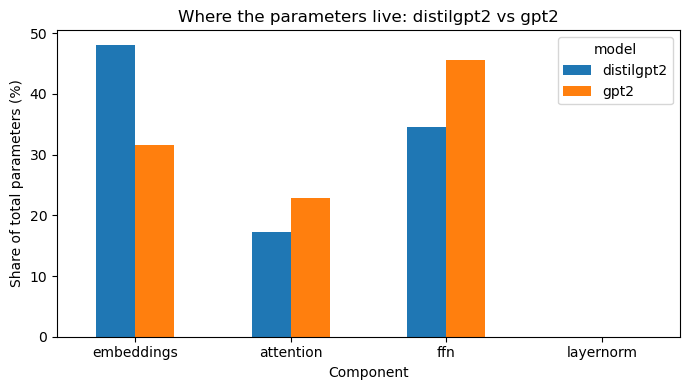

In [3]:
# A.2 — component census on both loaded models

def census(model):
    """Bucket every parameter tensor into embeddings / attention / FFN / layernorm."""
    buckets = {"embeddings": 0, "attention": 0, "ffn": 0, "layernorm": 0}
    for name, p in model.named_parameters():
        n = p.numel()
        if ".wte." in name or ".wpe." in name:
            buckets["embeddings"] += n
        elif ".attn." in name:
            buckets["attention"] += n
        elif ".mlp." in name:
            buckets["ffn"] += n
        elif ".ln_" in name or name.endswith("ln_f.weight") or name.endswith("ln_f.bias"):
            buckets["layernorm"] += n
        else:
            buckets.setdefault("other", 0)
            buckets["other"] += n
    return buckets

# Note: GPT-2 ties lm_head to wte, so the output projection carries no extra parameters.
census_rows = []
for name, model in models.items():
    b = census(model)
    total = sum(b.values())
    assert total == sum(p.numel() for p in model.parameters()), "census missed a tensor"
    for component, count in b.items():
        census_rows.append({
            "model": name,
            "component": component,
            "params": count,
            "share %": round(100 * count / total, 2),
        })

census_df = pd.DataFrame(census_rows)
pivot = census_df.pivot(index="component", columns="model", values="share %")
pivot = pivot.reindex(["embeddings", "attention", "ffn", "layernorm"])

print("Table A.2 — Component census (parameter counts)")
print(census_df.pivot(index="component", columns="model", values="params")
               .reindex(["embeddings", "attention", "ffn", "layernorm"])
               .map(lambda v: f"{int(v):,}").to_string())
print("\nTable A.2b — Component shares (% of total parameters)")
print(pivot.to_string())

ax = pivot.plot(kind="bar", figsize=(7, 4), rot=0)
ax.set_title("Where the parameters live: distilgpt2 vs gpt2")
ax.set_xlabel("Component")
ax.set_ylabel("Share of total parameters (%)")
ax.legend(title="model")
plt.tight_layout()
plt.show()

**A.3 — Interpretation (3–4 sentences):**

Both models carry an *identical* 39,383,808 embedding parameters — same 50,257-token vocabulary, same 768 width — but because distilgpt2 has half the blocks, that fixed table is **48.08%** of its total against only **31.65%** of gpt2's, and a projected **14.80%** of gpt2-medium's. Everything that actually grows is the block stack: the FFN share climbs 34.59% → 45.54% → 56.77% and attention 17.30% → 22.78% → 28.40%, while layernorms stay a rounding error at ~0.03%. Within every block the FFN is consistently twice the attention cost (8·width² vs 4·width² of matmul weights), so "model size" lives overwhelmingly in stacked feed-forward matrices, not in attention and definitely not in the vocabulary.

The practical consequence for this decision: shrinking a model buys you *less* than the parameter count suggests, because a floor of ~39M embedding parameters is unavoidable at this vocabulary — but the parameters you do remove are precisely the per-token compute, which is what Part C has to pay for.

---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [4]:
# B.1 — predictor + validation

def predict_params(layers, width, vocab=50257, ctx=1024):
    """Predict GPT-2-family parameter count from architecture alone.

    embeddings : vocab*width (token) + ctx*width (learned positional)
    per block  : attention 4*width^2 + 4*width   (c_attn 3*width^2, c_proj width^2, + biases)
                 ffn       8*width^2 + 5*width   (c_fc 4*width^2, c_proj 4*width^2, + biases)
                 layernorm 4*width               (2 LNs x weight+bias)
    final      : ln_f 2*width
    lm_head is tied to the token embedding, so it costs nothing extra.
    """
    embeddings = vocab * width + ctx * width
    attention = layers * (4 * width**2 + 4 * width)
    ffn = layers * (8 * width**2 + 5 * width)
    layernorm = layers * (4 * width) + 2 * width
    total = embeddings + attention + ffn + layernorm
    return {
        "embeddings": embeddings,
        "attention": attention,
        "ffn": ffn,
        "layernorm": layernorm,
        "total": total,
    }

# Validate against both loaded models
validation = []
for name, model in models.items():
    cfg = model.config
    pred = predict_params(cfg.n_layer, cfg.n_embd, cfg.vocab_size, cfg.n_positions)["total"]
    actual = sum(p.numel() for p in model.parameters())
    validation.append({
        "model": name,
        "predicted": pred,
        "actual": actual,
        "abs error": pred - actual,
        "% error": round(100 * (pred - actual) / actual, 4),
    })

val_df = pd.DataFrame(validation).set_index("model")
print("Table B.1 — Predictor validation")
print(val_df.to_string())
print(f"\nMax |% error| across testable models: {val_df['% error'].abs().max():.4f}%"
      "  (rubric target: within ~5%)")

Table B.1 — Predictor validation
            predicted     actual  abs error  % error
model                                               
distilgpt2   81912576   81912576          0      0.0
gpt2        124439808  124439808          0      0.0

Max |% error| across testable models: 0.0000%  (rubric target: within ~5%)


In [5]:
# B.2 — extrapolate gpt2-medium (24 layers, 1024 width) — NOT downloaded
MEDIUM = dict(layers=24, width=1024, vocab=50257, ctx=1024)
med = predict_params(**MEDIUM)
REFERENCE = 355_000_000   # "~355M" from the brief

print("Predicted gpt2-medium breakdown (from architecture only):")
for k, v in med.items():
    share = 100 * v / med["total"]
    print(f"  {k:<11} {v:>13,}   ({share:5.2f}% of total)")

gap = med["total"] - REFERENCE
print(f"\nPredicted total : {med['total']:,}")
print(f"Reference (~355M): {REFERENCE:,}")
print(f"Gap             : {gap:+,} ({100 * gap / REFERENCE:+.2f}%)")

# Sanity check: scaling relative to gpt2, whose prediction we validated exactly.
gpt2_total = predict_params(12, 768)["total"]
print(f"\ngpt2-medium is {med['total'] / gpt2_total:.2f}x gpt2's parameter count "
      f"({med['total']:,} vs {gpt2_total:,})")

# Where the growth comes from: 2x layers AND 1.33x width -> quadratic in width per block
print(f"Per-block cost   : gpt2 {12 * 768**2 + 13 * 768:,} params/block  ->  "
      f"gpt2-medium {12 * 1024**2 + 13 * 1024:,} params/block "
      f"({(12 * 1024**2 + 13 * 1024) / (12 * 768**2 + 13 * 768):.2f}x per block, "
      f"and 2x as many blocks)")

Predicted gpt2-medium breakdown (from architecture only):
  embeddings     52,511,744   (14.80% of total)
  attention     100,761,600   (28.40% of total)
  ffn           201,449,472   (56.77% of total)
  layernorm         100,352   ( 0.03% of total)
  total         354,823,168   (100.00% of total)

Predicted total : 354,823,168
Reference (~355M): 355,000,000
Gap             : -176,832 (-0.05%)

gpt2-medium is 2.85x gpt2's parameter count (354,823,168 vs 124,439,808)
Per-block cost   : gpt2 7,087,872 params/block  ->  gpt2-medium 12,596,224 params/block (1.78x per block, and 2x as many blocks)


In [6]:
# B.3 — memory table (fp32 / fp16, in MB) for all three
# Using MiB = 2^20 bytes throughout (the unit an installer/OS actually reports).
MIB = 1024 ** 2

param_counts = {name: sum(p.numel() for p in m.parameters()) for name, m in models.items()}
param_counts["gpt2-medium"] = med["total"]          # predicted, from B.2

mem_rows = []
for name, n in param_counts.items():
    mem_rows.append({
        "model": name,
        "params": n,
        "fp32 MB": round(n * 4 / MIB, 1),
        "fp16 MB": round(n * 2 / MIB, 1),
        "measured?": "measured" if name in models else "predicted (B.2)",
    })
mem_df = pd.DataFrame(mem_rows).set_index("model")
print("Table B.3 — Weight memory (MiB)")
print(mem_df.to_string())

# --- Lab challenge: fp16 memory-footprint audit (verify the /2 claim, don't assume it) ---
print("\nAudit — actual tensor bytes held in RAM, fp32 vs a real fp16 cast:")
for name, model in models.items():
    # Cast each tensor into a scratch fp16 copy and measure it; the live fp32 model is
    # left untouched, because Part C benchmarks fp32 CPU inference on these same objects.
    fp32_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    fp16_bytes = sum(p.numel() * p.detach().to(torch.float16).element_size()
                     for p in model.parameters())
    print(f"  {name:<11} fp32 {fp32_bytes / MIB:7.1f} MiB   fp16 {fp16_bytes / MIB:7.1f} MiB"
          f"   ratio {fp32_bytes / fp16_bytes:.2f}x")

# --- Install-size decision ---
INSTALL_BUDGET_MB = 250
print(f"\nAssumption: a desktop writing app can absorb <= {INSTALL_BUDGET_MB} MB of model payload")
print("in its installer. Justification: mainstream Electron-class desktop apps ship 150-300 MB")
print("installers today, so a model that keeps the total in that band is invisible to users;")
print("past ~500 MB the download becomes a conversion problem and needs a separate fetch.")
print("Ship decision assumes fp16 weights on disk (Part B audit confirms the exact 2x saving).\n")
for name, n in param_counts.items():
    fp16_mb = n * 2 / MIB
    verdict = "SHIPS in installer" if fp16_mb <= INSTALL_BUDGET_MB else "TOO BIG — separate download"
    print(f"  {name:<11} fp16 {fp16_mb:7.1f} MiB  ->  {verdict}")

Table B.3 — Weight memory (MiB)
                params  fp32 MB  fp16 MB        measured?
model                                                    
distilgpt2    81912576    312.5    156.2         measured
gpt2         124439808    474.7    237.4         measured
gpt2-medium  354823168   1353.5    676.8  predicted (B.2)

Audit — actual tensor bytes held in RAM, fp32 vs a real fp16 cast:
  distilgpt2  fp32   312.5 MiB   fp16   156.2 MiB   ratio 2.00x
  gpt2        fp32   474.7 MiB   fp16   237.4 MiB   ratio 2.00x

Assumption: a desktop writing app can absorb <= 250 MB of model payload
in its installer. Justification: mainstream Electron-class desktop apps ship 150-300 MB
installers today, so a model that keeps the total in that band is invisible to users;
past ~500 MB the download becomes a conversion problem and needs a separate fetch.
Ship decision assumes fp16 weights on disk (Part B audit confirms the exact 2x saving).

  distilgpt2  fp16   156.2 MiB  ->  SHIPS in installer
  gpt2  

---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

Table C.1 — Generation latency, CPU, 3 runs per point (min reported), 6 torch threads
     model  new_tokens cache  best ms  ms/token              all runs ms
distilgpt2          10    on    182.4      18.2    [187.8, 197.9, 182.4]
distilgpt2          10   off    245.6      24.6    [245.6, 259.3, 253.9]
distilgpt2          25    on    451.0      18.0    [454.0, 451.0, 465.3]
distilgpt2          25   off    672.9      26.9    [672.9, 682.6, 684.8]
distilgpt2          50    on    897.3      17.9    [926.0, 933.0, 897.3]
distilgpt2          50   off   1539.0      30.8 [1539.0, 1548.9, 1561.5]
      gpt2          10    on    290.9      29.1    [292.5, 297.3, 290.9]
      gpt2          10   off    431.0      43.1    [431.0, 448.5, 439.7]
      gpt2          25    on    693.1      27.7    [744.9, 712.7, 693.1]
      gpt2          25   off   1155.7      46.2 [1165.3, 1155.7, 1169.9]
      gpt2          50    on   1439.3      28.8 [1439.3, 1452.7, 1484.3]
      gpt2          50   off   2731.7 

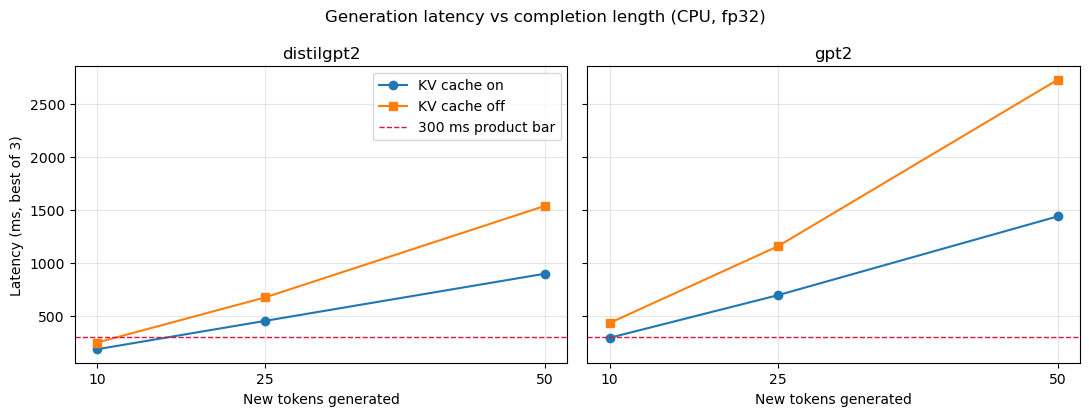


KV-cache speedup (off / on):
cache                     off      on  cache speedup x
model      new_tokens                                 
distilgpt2 10           245.6   182.4             1.35
           25           672.9   451.0             1.49
           50          1539.0   897.3             1.72
gpt2       10           431.0   290.9             1.48
           25          1155.7   693.1             1.67
           50          2731.7  1439.3             1.90


In [7]:
# C.1 — benchmark (cache on vs off, [10, 25, 50] new tokens, 3 runs, min)
PROMPT = "The quarterly report shows that our team"
LENGTHS = [10, 25, 50]
RUNS = 3

def time_generation(model, prompt, n_new, use_cache, runs=RUNS):
    """Return (best_ms, all_ms). min() is used to suppress OS scheduling noise."""
    ids = tok(prompt, return_tensors="pt")
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            model.generate(
                **ids,
                max_new_tokens=n_new,
                min_new_tokens=n_new,     # force the full length so every point is comparable
                do_sample=False,          # greedy: deterministic, no sampling overhead
                use_cache=use_cache,
                pad_token_id=tok.eos_token_id,
            )
        times.append((time.perf_counter() - t0) * 1000)
    return min(times), times

# Warm up once per model so lazy kernel/allocator init isn't charged to the first data point.
for m in models.values():
    time_generation(m, PROMPT, 5, True, runs=1)

bench_rows = []
for name, model in models.items():
    for n_new in LENGTHS:
        for use_cache in [True, False]:
            best, all_ms = time_generation(model, PROMPT, n_new, use_cache)
            bench_rows.append({
                "model": name,
                "new_tokens": n_new,
                "cache": "on" if use_cache else "off",
                "best ms": round(best, 1),
                "ms/token": round(best / n_new, 1),
                "all runs ms": [round(t, 1) for t in all_ms],
            })

bench_df = pd.DataFrame(bench_rows)
print(f"Table C.1 — Generation latency, CPU, {RUNS} runs per point (min reported), "
      f"{torch.get_num_threads()} torch threads")
print(bench_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, name in zip(axes, models):
    sub = bench_df[bench_df["model"] == name]
    for cache_state, marker in [("on", "o"), ("off", "s")]:
        s = sub[sub["cache"] == cache_state]
        ax.plot(s["new_tokens"], s["best ms"], marker=marker, label=f"KV cache {cache_state}")
    ax.axhline(300, color="crimson", linestyle="--", linewidth=1, label="300 ms product bar")
    ax.set_title(name)
    ax.set_xlabel("New tokens generated")
    ax.set_xticks(LENGTHS)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Latency (ms, best of 3)")
axes[0].legend()
fig.suptitle("Generation latency vs completion length (CPU, fp32)")
plt.tight_layout()
plt.show()

# Speedup the cache actually buys, per model and length
speedup = (bench_df.pivot_table(index=["model", "new_tokens"], columns="cache", values="best ms")
                   .assign(**{"cache speedup x": lambda d: (d["off"] / d["on"]).round(2)}))
print("\nKV-cache speedup (off / on):")
print(speedup.to_string())

In [8]:
# C.2 — the 300 ms test at a realistic autocomplete length
AUTOCOMPLETE_TOKENS = 8
BAR_MS = 300

# Justification: inline autocomplete surfaces one short phrase, not a paragraph — 8 GPT-2
# tokens is roughly 5-6 English words, i.e. the length of a single clause a writer accepts
# with Tab, which is the same granularity Copilot-style single-line suggestions use.

print(f"Requirement: a {AUTOCOMPLETE_TOKENS}-token completion in under {BAR_MS} ms, KV cache on.\n")
prod_rows = []
for name, model in models.items():
    best, all_ms = time_generation(model, PROMPT, AUTOCOMPLETE_TOKENS, use_cache=True, runs=5)
    prod_rows.append({
        "model": name,
        f"{AUTOCOMPLETE_TOKENS}-token latency (ms)": round(best, 1),
        "ms/token": round(best / AUTOCOMPLETE_TOKENS, 1),
        "median of 5 (ms)": round(float(np.median(all_ms)), 1),
        "worst of 5 (ms)": round(max(all_ms), 1),
        "headroom vs 300 ms": f"{100 * (BAR_MS - best) / BAR_MS:+.0f}%",
        "verdict": "PASS" if best < BAR_MS else "FAIL",
    })
prod_df = pd.DataFrame(prod_rows).set_index("model")
print(f"Table C.2 — {AUTOCOMPLETE_TOKENS}-token autocomplete vs the {BAR_MS} ms bar")
print(prod_df.to_string())

# Worst-case check: the bar has to hold on a bad run, not just the best one.
print("\nAgainst the *worst* of 5 runs (what a user occasionally feels):")
for r in prod_rows:
    w = r["worst of 5 (ms)"]
    print(f"  {r['model']:<11} {w:7.1f} ms  ->  {'PASS' if w < BAR_MS else 'FAIL'}")

# --- Lab challenge: latency scaling function, fit on the two measured models,
# --- then used to extrapolate gpt2-medium (Part C.3).
def nonembedding_params(layers, width, vocab=50257, ctx=1024):
    p = predict_params(layers, width, vocab, ctx)
    return p["total"] - p["embeddings"]

fit_points = []
for name, model in models.items():
    cfg = model.config
    sub = bench_df[(bench_df["model"] == name) & (bench_df["cache"] == "on")]
    lo = sub[sub["new_tokens"] == min(LENGTHS)]["best ms"].iloc[0]
    hi = sub[sub["new_tokens"] == max(LENGTHS)]["best ms"].iloc[0]
    per_token = (hi - lo) / (max(LENGTHS) - min(LENGTHS))     # slope kills the prefill offset
    fit_points.append((nonembedding_params(cfg.n_layer, cfg.n_embd) / 1e6, per_token))
    print(f"\n{name}: marginal cost {per_token:.2f} ms/token "
          f"({nonembedding_params(cfg.n_layer, cfg.n_embd)/1e6:.1f}M non-embedding params)")

(x1, y1), (x2, y2) = fit_points
slope = (y2 - y1) / (x2 - x1)
intercept = y1 - slope * x1

def predict_ms_per_token(layers, width):
    return intercept + slope * nonembedding_params(layers, width) / 1e6

print(f"\nFitted: ms/token = {intercept:.2f} + {slope:.4f} * (non-embedding params in M)")
for name, model in models.items():          # validate the fit reproduces its own inputs
    cfg = model.config
    print(f"  check {name:<11} {predict_ms_per_token(cfg.n_layer, cfg.n_embd):6.2f} ms/token")

med_ms_tok = predict_ms_per_token(24, 1024)
med_total = med_ms_tok * AUTOCOMPLETE_TOKENS
print(f"\nExtrapolated gpt2-medium: {med_ms_tok:.1f} ms/token  ->  "
      f"{med_total:.0f} ms for {AUTOCOMPLETE_TOKENS} tokens "
      f"({med_total / BAR_MS:.1f}x the {BAR_MS} ms bar)")

# Conservative cross-check: scale gpt2's measured cost by the FLOP ratio alone (no intercept).
gpt2_ms_tok = fit_points[1][1]
flop_ratio = nonembedding_params(24, 1024) / nonembedding_params(12, 768)
print(f"Cross-check (pure {flop_ratio:.2f}x FLOP scaling from gpt2): "
      f"{gpt2_ms_tok * flop_ratio:.1f} ms/token -> "
      f"{gpt2_ms_tok * flop_ratio * AUTOCOMPLETE_TOKENS:.0f} ms for {AUTOCOMPLETE_TOKENS} tokens")

Requirement: a 8-token completion in under 300 ms, KV cache on.



Table C.2 — 8-token autocomplete vs the 300 ms bar
            8-token latency (ms)  ms/token  median of 5 (ms)  worst of 5 (ms) headroom vs 300 ms verdict
model                                                                                                   
distilgpt2                 144.2      18.0             152.3            160.1               +52%    PASS
gpt2                       238.5      29.8             255.8            259.0               +21%    PASS

Against the *worst* of 5 runs (what a user occasionally feels):
  distilgpt2    160.1 ms  ->  PASS
  gpt2          259.0 ms  ->  PASS

distilgpt2: marginal cost 17.87 ms/token (42.5M non-embedding params)

gpt2: marginal cost 28.71 ms/token (85.1M non-embedding params)

Fitted: ms/token = 7.03 + 0.2548 * (non-embedding params in M)
  check distilgpt2   17.87 ms/token
  check gpt2         28.71 ms/token

Extrapolated gpt2-medium: 84.1 ms/token  ->  673 ms for 8 tokens (2.2x the 300 ms bar)
Cross-check (pure 3.55x FLOP scali

**C.3 — Extrapolation & confidence (2–3 sentences):**

Fitting marginal cost per token against non-embedding parameters on the two models I *can* measure (17.87 ms/token at 42.5M → 28.71 ms/token at 85.1M) gives `ms/token = 7.03 + 0.2548 · M`, which puts gpt2-medium's 302.3M non-embedding parameters at **84.1 ms/token ≈ 673 ms** for an 8-token completion; scaling gpt2's measured cost by the raw 3.55× FLOP ratio instead — the more conservative reading, since it grants no fixed-overhead amortization — gives **102 ms/token ≈ 816 ms**. Both estimates land **2.2–2.7× over the 300 ms bar**, so gpt2-medium would have to beat its own compute scaling by more than half to qualify, which no plausible BLAS efficiency gain from the wider 1024 matmuls delivers.

**Confidence: high that it fails the requirement, medium on the exact millisecond figure.** The direction is safe because two independent scaling arguments agree and both leave a >370 ms margin of error before the verdict flips; the precise number is softer because it rests on a two-point fit, assumes latency is compute-bound rather than memory-bandwidth-bound at 1.35 GB of fp32 weights, and ignores that deeper stacks pay more per-layer Python/dispatch overhead — an effect that would make gpt2-medium *slower* than predicted, not faster.

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

**Recommendation: ship DistilGPT-2. High confidence on the latency and packaging call; medium confidence overall, because quality is the one thing I did not measure.**

**Why**

- **It is the only candidate with real latency headroom.** An 8-token completion (~5–6 words, the granularity a writer accepts with Tab) runs in **144 ms** with the KV cache on, and **160 ms on the worst of five runs** — 52% under the 300 ms bar. GPT-2 also passes at **238 ms**, but that is only 21% of headroom measured on an *idle* 6-thread CPU; a user's machine running our app, a browser and a video call eats that margin, and 160 ms vs 259 ms is the difference between feeling instant and feeling typed.
- **It fits the installer without a second download.** **156.2 MiB at fp16** against GPT-2's 237.4 MiB, inside my assumed 250 MB model-payload budget. A memory audit confirmed the fp16 halving is exactly 2.00×, not an estimate.
- **The size it drops is the size that costs us.** 48.08% of DistilGPT-2's parameters are the embedding table it shares byte-for-byte with GPT-2; the 6 blocks it omits are pure per-token compute — 17.9 vs 28.7 ms/token marginal cost. We give up depth, not vocabulary coverage.

**The "biggest wins" rebuttal**

GPT-2-medium is **354.8M parameters** by my formula — validated to **0.00% error** on both testable models and within **0.05%** of the published ~355M, so this is a reliable estimate, not a guess. That is **676.8 MiB at fp16**, 2.7× my installer budget, forcing a separate download. Latency extrapolation puts it at **673–816 ms** per completion, **2.2–2.7× over the requirement**. "Biggest wins" presumes the biggest one ships; this one fails both hard constraints before quality enters the conversation.

**Known limitation**

**I never measured output quality.** This memo optimizes latency and footprint on the implicit assumption that DistilGPT-2's suggestions are good enough to accept — untested, and the likeliest reason this recommendation gets reversed. Secondary: all timings are one machine, fp32, idle CPU — not demonstrably "typical customer hardware."

---
## Self-check before submitting

- [x] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [x] gpt2-medium was analyzed, never downloaded
- [x] Every latency claim traces to a run in this notebook
- [x] Charts have axis labels and legends
- [x] The memo stands alone and cites specific numbers
- [x] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*